## **Messwerte**

In [31]:
import numpy as np

c_spezifisch_wasser = 4190 #Wärmekapazität von Wasser in J/Kg*K

c_spezifisch_Kaloriemeter = 1 #TODO
c_spezifisch_Kaloriemeter_Fehler = 1 #TODO

T_Siede = 373.15 #Siedetemperatur in Kelvin #TODO

"""-------------------------------------------------------------------------------------------------------------------------"""

m_wasser_kalt_1 = 1 #Masse des kalten Wassers im Kaloriemeter in kg
m_wasser_kalt_1_Fehler = 0

m_Dampf_1 = 1 #Masse des eigeleiteten Dampfs in kg
m_Dampf_1_Fehler = 0

T_Fehler_1 = 0.1

zeiten_Vorkurve_1 = np.array([30, 60, 90, 120, 150, 180]) #Zeiten bis Temperatursprung (erweitern falls Nötig) in Kelvin

T_Kalorimeter_vorher_1 = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6])


zeiten_hauptkurve_1 = zeiten_Vorkurve_1[-1] +  np.array([10, 20, 30, 40, 50, 60, 70, 80, 90])

T_Kalorimeter_zugabe_1 = np.array([1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5]) #Temperaturen nach Dampfzugabe über 90 Sekunden alle 10 Sekunden



zeiten_nachkurve_1 = zeiten_hauptkurve_1[8] + np.array([30, 60, 90, 120])

T_Kalorimeter_zugabe_lanfristig_1 = np.array([2.4, 2.3, 2.2, 2.1]) #Temperaturen nach Abstöpseln des Dampes über 2 Minuten alle 30 Sekunden


"""-------------------------------------------------------------------------------------------------------------------------------------------------------"""

m_wasser_kalt_2 = 1 #Masse des kalten Wassers im Kaloriemeter in kg
m_wasser_kalt_2_Fehler = 0

m_Dampf_2 = 1 #Masse des eigeleiteten Dampfs in kg
m_Dampf_2_Fehler = 0

T_Fehler_2 = 0.1

zeiten_Vorkurve_2 = np.array([30, 60, 90, 120, 150, 180]) #Zeiten bis Temperatursprung (erweitern falls Nötig) in Kelvin

T_Kalorimeter_vorher_2 = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6])


zeiten_hauptkurve_2 = zeiten_Vorkurve_2[-1] +  np.array([10, 20, 30, 40, 50, 60, 70, 80, 90])

T_Kalorimeter_zugabe_2 = np.array([1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5]) #Temperaturen nach Dampfzugabe über 90 Sekunden alle 10 Sekunden



zeiten_nachkurve_2 = zeiten_hauptkurve_2[8] + np.array([30, 60, 90, 120])

T_Kalorimeter_zugabe_lanfristig_2 = np.array([2.4, 2.3, 2.2, 2.1]) #Temperaturen nach Abstöpseln des Dampes über 2 Minuten alle 30 Sekunden





## **Plots**

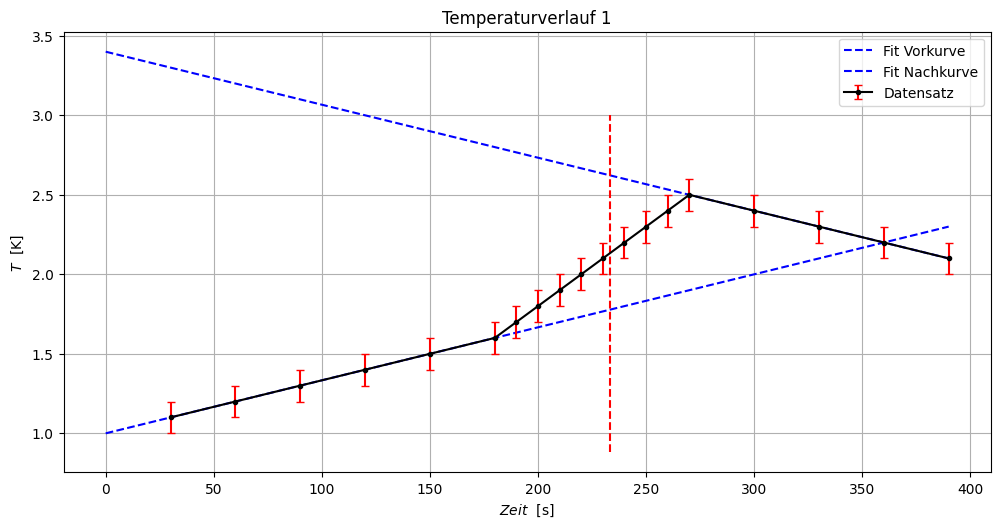

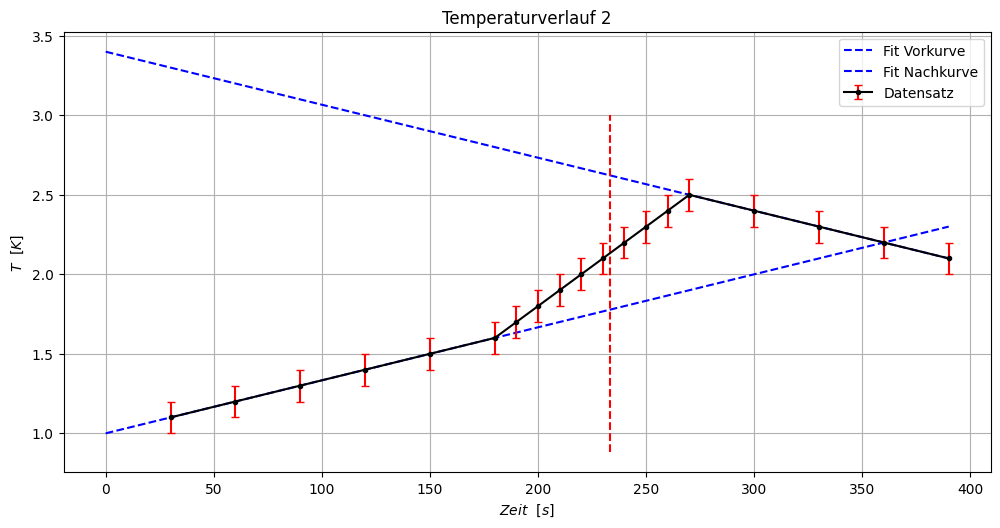

In [32]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import simpson
from scipy.optimize import fsolve
from scipy.integrate import quad

def f(x,k,a):
    return k*x +a

A_messung_1 = simpson(y=T_Kalorimeter_zugabe_1, x=zeiten_hauptkurve_1)
A_messung_2 = simpson(y=T_Kalorimeter_zugabe_2, x=zeiten_hauptkurve_2)

xwerte = np.linspace(0, np.max(zeiten_nachkurve_1), 1000)

def Dreiecksflaechen(xval, vork, nachk, A_messung, zeiten_hauptkurve ):
    xval = xval[0] if isinstance(xval, (list, np.ndarray)) else xval

    if xval >= zeiten_hauptkurve[-1] or xval <= zeiten_hauptkurve[0]:
        return 100e6


    A1, _ = quad(vork, zeiten_hauptkurve[0], xval)
    A2, _ = quad(nachk, xval, zeiten_hauptkurve[-1])

    A_theorie = A1 + A2

    return A_theorie - A_messung

fig, ax1 = plt.subplots(1,1, figsize = (10,5))
fig.tight_layout()

"""----------------------------------------------------------------------------------------------------------------------------------------------------------"""

#Lineare Fits für Vor- und Nachkurve

coeficcients_1V, pcov = curve_fit(f, zeiten_Vorkurve_1, T_Kalorimeter_vorher_1, sigma=T_Fehler_1, absolute_sigma=True)

def Vorkurve1(x):
    return coeficcients_1V[0]*x + coeficcients_1V[1]

ax1.plot(xwerte, Vorkurve1(xwerte), "b--", label = "Fit Vorkurve")


coeficcients_1N, pcov = curve_fit(f, zeiten_nachkurve_1, T_Kalorimeter_zugabe_lanfristig_1, sigma=T_Fehler_1, absolute_sigma=True)

def Nachkurve1(x):
    return coeficcients_1N[0]*x + coeficcients_1N[1]

ax1.plot(xwerte,Nachkurve1(xwerte), "b--", label = "Fit Nachkurve")

"""---------------------------------------------------------------------------------------------------------------------------------------------------------------"""
#Temperaturen mit dem Zwickelabgleich finden

h_1 = fsolve(Dreiecksflaechen, np.median(zeiten_hauptkurve_1) , args = (Vorkurve1, Nachkurve1, A_messung_1, zeiten_hauptkurve_1))[0]
ax1.vlines(h_1, ymin=np.min(T_Kalorimeter_vorher_1)*0.8, ymax=np.max(T_Kalorimeter_zugabe_1)*1.2, color = "red", linestyle = "dashed")

T_Zugabe_1 = Vorkurve1(h_1)
T_final_1 = Nachkurve1(h_1)

ax1.errorbar(np.concatenate((zeiten_Vorkurve_1, zeiten_hauptkurve_1, zeiten_nachkurve_1), axis = 0), np.concatenate((T_Kalorimeter_vorher_1, T_Kalorimeter_zugabe_1, T_Kalorimeter_zugabe_lanfristig_1) ,axis=0), yerr = T_Fehler_1, fmt = "o-", label = "Datensatz", color = "black", markersize  = 3 , capsize = 3, ecolor = "r")

#ax1.hlines(T_final_1, xmin = 0, xmax = 480, color = "orange", linestyles= "dashed", label = "Finale Mischtemperatur")

#ax1.hlines(T_Zugabe_1, xmin = 0, xmax = 480, color = "purple", linestyles= "dashed", label = "Temperatur Zugabe kaltes Wasser")

ax1.set_xlabel("$Zeit~~[\\mathrm{s}]$")
ax1.set_ylabel("$T~~[\\mathrm{K}]$")
ax1.grid(True)
ax1.set_title("Temperaturverlauf 1")
ax1.legend()


"""---------------------------------------------------------------------------------------------------------------------------------------------------------------"""
fig, ax2 = plt.subplots(1,1, figsize = (10,5))
fig.tight_layout()

#Lineare Fits für Vor- und Nachkurve

coeficcients_2V, pcov = curve_fit(f, zeiten_Vorkurve_2, T_Kalorimeter_vorher_2, sigma=T_Fehler_2, absolute_sigma=True)

def Vorkurve2(x):
    return coeficcients_2V[0]*x + coeficcients_2V[1]

ax2.plot(xwerte, Vorkurve2(xwerte), "b--", label = "Fit Vorkurve")


coeficcients_2N, pcov = curve_fit(f, zeiten_nachkurve_2, T_Kalorimeter_zugabe_lanfristig_2, sigma=T_Fehler_2, absolute_sigma=True)

def Nachkurve2(x):
    return coeficcients_2N[0]*x + coeficcients_2N[1]

ax2.plot(xwerte,Nachkurve2(xwerte), "b--", label = "Fit Nachkurve")

"""---------------------------------------------------------------------------------------------------------------------------------------------------------------"""
#Temperaturen mit dem Zwickelabgleich finden

h_2 = fsolve(Dreiecksflaechen, np.median(zeiten_hauptkurve_2) , args = (Vorkurve2, Nachkurve2, A_messung_2, zeiten_hauptkurve_2))[0]
ax2.vlines(h_2, ymin=np.min(T_Kalorimeter_vorher_2)*0.8, ymax=np.max(T_Kalorimeter_zugabe_2)*1.2, color = "red", linestyle = "dashed")

T_Zugabe_2 = Vorkurve2(h_2)
T_final_2 = Nachkurve2(h_2)


ax2.errorbar(np.concatenate((zeiten_Vorkurve_2, zeiten_hauptkurve_2, zeiten_nachkurve_2), axis = 0), np.concatenate((T_Kalorimeter_vorher_2, T_Kalorimeter_zugabe_2, T_Kalorimeter_zugabe_lanfristig_2) ,axis=0), yerr = T_Fehler_2, fmt = "o-", label = "Datensatz", color = "black", markersize  = 3 , capsize = 3, ecolor = "r")

#ax2.hlines(T_final_2, xmin = 0, xmax = 480, color = "orange", linestyles= "dashed", label = "Finale Mischtemperatur")

#ax2.hlines(T_Zugabe_2, xmin = 0, xmax = 480, color = "purple", linestyles= "dashed", label = "Temperatur Zugabe kaltes Wasser")

ax2.set_xlabel("$Zeit~~[s]$")
ax2.set_ylabel("$T~~[K]$")
ax2.grid(True)
ax2.set_title("Temperaturverlauf 2")
ax2.legend()

## **Berechnung der spezifischen Verdampfungswärme**

In [33]:
from Skripte.Fehlerfortpflanzung import Gaußfehler
from IPython.display import display
import sympy


L_1 = ((m_wasser_kalt_1*c_spezifisch_wasser + c_spezifisch_Kaloriemeter)*(T_final_1 - T_Zugabe_1) - m_Dampf_1*c_spezifisch_wasser*(T_Siede - T_final_1)) / m_Dampf_1

mw, cw, Ck, Tf, Tz, mD, Ts = sympy.symbols("m_wasser, c_wasser, C_kalo, T_final, T_zugabe, m_Dampf, T_siede")

expr1 = ((mw*cw + Ck)*(Tf - Tz) - mD*cw*(Ts - Tf)) / mD
display(expr1)

Variablen = np.array([mw, cw, Ck, Tf, Tz, mD, Ts])

Mittelwerte_1 = np.array([m_wasser_kalt_1, c_spezifisch_wasser, c_spezifisch_Kaloriemeter, T_final_1, T_Zugabe_1, m_Dampf_1, T_Siede])
Fehler_1 = np.array([m_wasser_kalt_1_Fehler, 0, c_spezifisch_Kaloriemeter_Fehler, T_Fehler_1, T_Fehler_1, m_Dampf_1_Fehler, 0])

L_1_Fehler = Gaußfehler(expr1, Variablen, Mittelwerte_1, Fehler_1)

print(f"\nspezifische Verdampfungswärme von Wasser (1) L = {L_1} +/- {L_1_Fehler} J/kg (Soll: 2257000 J/kg")


L_2 = ((m_wasser_kalt_2*c_spezifisch_wasser + c_spezifisch_Kaloriemeter)*(T_final_2 - T_Zugabe_2) - m_Dampf_2*c_spezifisch_wasser*(T_Siede - T_final_2)) / m_Dampf_2

Mittelwerte_2 = np.array([m_wasser_kalt_2, c_spezifisch_wasser, c_spezifisch_Kaloriemeter, T_final_2, T_Zugabe_2, m_Dampf_2, T_Siede])
Fehler_2 = np.array([m_wasser_kalt_2_Fehler, 0, c_spezifisch_Kaloriemeter_Fehler, T_Fehler_2, T_Fehler_2, m_Dampf_2_Fehler, 0])

L_2_Fehler = Gaußfehler(expr1, Variablen, Mittelwerte_2, Fehler_2)

print(f"\nspezifische Verdampfungswärme von Wasser (2) L = {L_2} +/- {L_2_Fehler} J/kg (Soll: 2257000 J/kg")

(-c_wasser*m_Dampf*(-T_final + T_siede) + (C_kalo + c_wasser*m_wasser)*(T_final - T_zugabe))/m_Dampf


spezifische Verdampfungswärme von Wasser (1) L = -1548963.1401053823 +/- 937.0470295324326 J/kg (Soll: 2257000 J/kg

spezifische Verdampfungswärme von Wasser (2) L = -1548963.1401053823 +/- 937.0470295324326 J/kg (Soll: 2257000 J/kg
